# 1141 Assignment 02
Editor: Xuan-Wei Wang

# Yield Classification and Analysis

In [1]:
import pandas as pd

# 1. 讀取特徵資料 (secom.data)
# sep='\s+' 代表使用「一個或多個空格」作為分隔符號
df_features = pd.read_csv('secom.data', sep='\s+', header=None)

# 2. 讀取標籤資料 (secom_labels.data)
df_labels = pd.read_csv('secom_labels.data', sep='\s+', header=None, names=['result', 'timestamp'])

# 3. 合併成一個完整的 DataFrame (方便後續分析)
# 我們只需要標籤的第一欄 (result)
df = pd.concat([df_features, df_labels['result']], axis=1)

# 看看前幾列長什麼樣子
print(df.head())

         0        1          2          3       4      5         6       7  \
0  3030.93  2564.00  2187.7333  1411.1265  1.3602  100.0   97.6133  0.1242   
1  3095.78  2465.14  2230.4222  1463.6606  0.8294  100.0  102.3433  0.1247   
2  2932.61  2559.94  2186.4111  1698.0172  1.5102  100.0   95.4878  0.1241   
3  2988.72  2479.90  2199.0333   909.7926  1.3204  100.0  104.2367  0.1217   
4  3032.24  2502.87  2233.3667  1326.5200  1.5334  100.0  100.3967  0.1235   

        8       9  ...       581     582     583     584      585     586  \
0  1.5005  0.0162  ...       NaN  0.5005  0.0118  0.0035   2.3630     NaN   
1  1.4966 -0.0005  ...  208.2045  0.5019  0.0223  0.0055   4.4447  0.0096   
2  1.4436  0.0041  ...   82.8602  0.4958  0.0157  0.0039   3.1745  0.0584   
3  1.4882 -0.0124  ...   73.8432  0.4990  0.0103  0.0025   2.0544  0.0202   
4  1.5031 -0.0031  ...       NaN  0.4800  0.4766  0.1045  99.3032  0.0202   

      587     588       589  result  
0     NaN     NaN       NaN   

In [2]:
print(df.shape)
print(df['result'].value_counts())

(1567, 591)
result
-1    1463
 1     104
Name: count, dtype: int64


## Data Science Framework
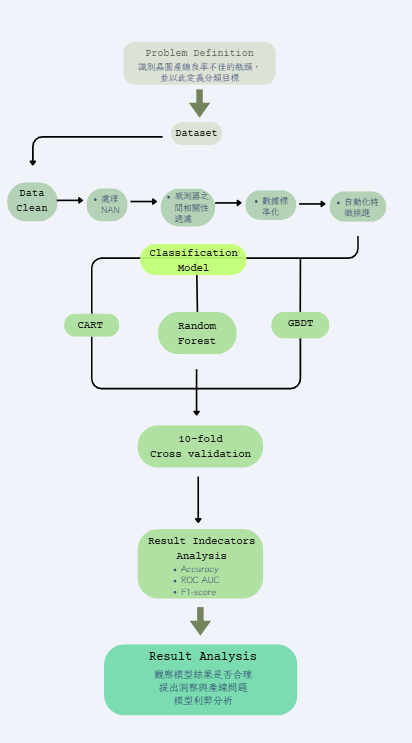
1. Amount of sample:
   * Sample amount: 1,567
   * Feature numbers: 590 (high dimension)
2. Data class:
   * Pass ( $-1$ ): 1,463 (93.4%) 
   * Fail ( $1$ ): 104 (6.6%)
   * Unbalanced dataset!
3. Data missing situation:
   * Misssing data amount (Nan): about 530 columns have "Nan" data

In [3]:
### <<< 看缺失的多少
nan_per_column = df.isnull().sum()
# 只看有缺失值的欄位，並由多到少排序
nan_summary = nan_per_column[nan_per_column > 0].sort_values(ascending=False)
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage.sort_values(ascending=False).head(10)) # 顯示前10名嚴重的欄位

292    91.193363
293    91.193363
157    91.193363
158    91.193363
220    85.577537
358    85.577537
85     85.577537
492    85.577537
382    64.964901
384    64.964901
dtype: float64


In [4]:
# 檢查整行完全相同的重複樣本數量
duplicate_count = df.duplicated().sum()
print(f"Total duplicated samples: {duplicate_count}")

Total duplicated samples: 0


## Data Preprocessing

| Quality Dimension | Checkpoint | Initial Findings (SECOM Dataset) | Manufacturing Context |
| :--- | :--- | :--- | :--- |
| **Missing Values** | Presence of NaN values | Significant number of missing values across various sensor columns (e.g., Sensor 157). | May indicate sensor failure, downtime, or data logging errors. |
| **Redundant Features** | Constant or zero-variance columns | Several features have a standard deviation of 0 (Constant features). | These sensors provide zero information gain as they do not vary with the process. |
| **Duplicated Samples** | Identical observations | No duplicated samples| Duplicate samples can lead to model overfitting to specific process batches. |
| **Outliers** | Values outside physical limits | Extreme values detected in certain sensor distributions. | Represents instrument drift or extreme anomalous process events. |

| Preprocessing Action | Specific Method | Rationale |
| :--- | :--- | :--- |
| **Feature Selection** | Drop all columns with zero standard deviation (std = 0). | Reduces model complexity and avoids the "Curse of Dimensionality" by removing non-informative noise. |
| **Imputation** | Remove columns with >50% missingness; others filled by **Median**. | Median is robust to outliers, making it superior to mean for skewed manufacturing sensor data. |
| **Outlier Treatment** | Z-score detection or Interquartile Range (IQR) clipping. | Prevents extreme values from distorting CART split points, ensuring a more stable model. |
| **Standardization** | Apply Z-score scaling (StandardScaler). | Harmonizes different units (e.g., Pressure vs. Temp), which is essential for consistent model comparison. |

In [7]:
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

constant_cols = [col for col in df.columns if df[col].std() == 0]
df_no_constant = df.drop(columns=constant_cols)
print(f"Removed {len(constant_cols)} constant features.")

missing_threshold = 0.5
cols_to_drop = df_no_constant.columns[df_no_constant.isnull().mean() > missing_threshold]
df_dropped = df_no_constant.drop(columns=cols_to_drop)

df_dropped.columns = df_dropped.columns.astype(str)
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df_dropped), columns=df_dropped.columns)

scaler = StandardScaler()
df_final = pd.DataFrame(scaler.fit_transform(df_imputed), columns=df_imputed.columns)

print("Preprocessing Complete!")
print(f"Final data shape: {df_final.shape}")
print(df_final.head())

Removed 116 constant features.
Preprocessing Complete!
Final data shape: (1567, 447)
          0         1         2         3         4         6         7  \
0  0.224463  0.849523 -0.436430  0.035804 -0.050121 -0.564354  0.265894   
1  1.107287 -0.383106  1.016977  0.155282 -0.059585  0.197639  0.321868   
2 -1.114000  0.798901 -0.481447  0.688278 -0.047447 -0.906768  0.254699   
3 -0.350156 -0.199072 -0.051705 -1.104376 -0.050831  0.502662 -0.013974   
4  0.242296  0.087328  1.117227 -0.156616 -0.047033 -0.115954  0.187531   

          8         9        10  ...       577       582        583  \
0  0.509848  1.128455 -0.381577  ... -0.135520  0.118679  -0.204833   
1  0.457021  0.022620 -1.608281  ... -0.460054  0.530183   0.406734   
2 -0.260885  0.327222  0.124169  ... -0.590505 -1.262799   0.022320   
3  0.343240 -0.765369 -0.370817  ... -0.645708 -0.322218  -0.292200   
4  0.545066 -0.149545 -0.790478  ... -0.454486 -5.906917  26.867221   

         584        585       586    

In [8]:
df_final.to_csv('SECOM_preprocessed_data.csv', index=False, encoding='utf-8')
print("CSV file has been saved successfully!")

CSV file has been saved successfully!


## CART Classification (Original dataset)
Using CART classification model to predict and analysis.

In [15]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold

x=df_final.drop(columns=['result'])
# 1. 確保標籤 y 是純整數的一維陣列（只取第一欄並轉換）
y = df_labels.iloc[:, 0].values.astype(int)
print(f"Unique labels: {np.unique(y)}") # 應該顯示 [-1  1]
print(f"Label type: {y.dtype}")        # 應該顯示 int32 或 int64

# 2. 初始化 CART 模型
cart_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

# 3. 設定 10-fold 交叉驗證
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy', 'roc_auc', 'f1']

# 4. 執行交叉驗證 (關鍵修正：使用變數 y，而不是 df_labels)
cv_results = cross_validate(cart_model, x, y, cv=cv, scoring=scoring)

# 5. 印出平均績效
print(f"\n--- CART Model Performance (Original Data) ---")
print(f"Average Accuracy: {cv_results['test_accuracy'].mean():.4f}")
print(f"Average ROC AUC : {cv_results['test_roc_auc'].mean():.4f}")
print(f"Average F1-score: {cv_results['test_f1'].mean():.4f}")

Unique labels: [-1  1]
Label type: int64

--- CART Model Performance (Original Data) ---
Average Accuracy: 0.9107
Average ROC AUC : 0.6257
Average F1-score: 0.1203


### Model Hyperparameters
* Criterion: Gini impurity
* Max depth for decision tree: 5
* Min samples split: 10
* Random state: 42
* Class weight: None (2 classes are equal)

### Model Performance
* Average Accuracy: 0.9107
* Average ROC AUC : 0.6257
* Average F1-score: 0.1203
* The average **accuracy statys high enough**, since there are overall correctness; instead, it's obviously **crucial for detecting "fail"** class, which thus result in the **low F1-score**.

## Solving Unbalanced Dataset


We deal with the unbalanced dataset from the following 2 aspects:
1. Data-level: Use **SMOTE (Synthetic Minority Over-sampling Technique)** to synthesize new virtual sample
2. Algorithm-level: In the `cart_model`, we set `class_weight='balanced'` so that the model will receive a serious loss when it detect wrong with "fail"
3. Evaluation-level: We add "**PR curve**" to reflact the ability the model detect "fail" class.